<a href="https://colab.research.google.com/github/gvingm/CV_Albert_Galiaberov_BDM/blob/main/%D0%A2%D1%80%D0%B0%D0%BD%D1%81%D0%BA%D1%80%D0%B8%D0%B1%D0%B0%D1%86%D0%B8%D1%8F_ipynb_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

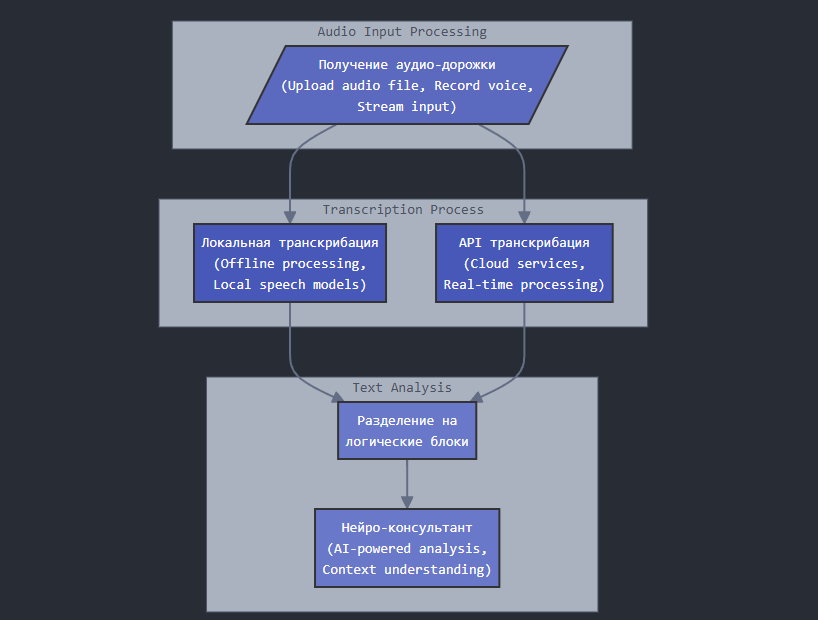

In [ ]:
# @title Устанавливаем whisper и yt-dlp
!pip -q install yt-dlp -U # Устанавливаем библиотеку для загрузки звука с видео. документация https://github.com/yt-dlp/yt-dlp?tab=readme-ov-file#readme
!pip install git+https://github.com/openai/whisper.git
from IPython.display import clear_output
clear_output()

In [ ]:
!pip install -q tiktoken==0.7.0 openai==1.41.1 langchain==0.2.14 langchain_community==0.2.12 langchain-openai==0.1.22 faiss-cpu==1.8.0 python-docx==1.1.0
from IPython.display import clear_output
clear_output()

In [ ]:
import whisper
import os
import gdown
import requests
import re
import time
from IPython.display import HTML, clear_output
import subprocess
from pathlib import Path
import json
import tiktoken
from docx import Document
from docx.enum.text import WD_PARAGRAPH_ALIGNMENT
import ipywidgets as widgets
from IPython.display import display
from tqdm.auto import tqdm
import getpass
import pickle
from urllib.request import urlopen
import openai
import subprocess
import codecs
from langchain.chains import ConversationChain         # Импортируем класс для создания цепочек диалогов
from langchain_openai import ChatOpenAI           # Импортируем класс для работы с чатами на базе OpenAI
from langchain_openai import OpenAI
from langchain.memory import ConversationBufferMemory  # Импортируем класс для управления памятью диалогов
from langchain.text_splitter import MarkdownHeaderTextSplitter, RecursiveCharacterTextSplitter
import os
import glob
import shutil
import urllib

## Получение аудио-дорожки из видео по ссылке и загрузка в колаб

In [ ]:
import yt_dlp

# Ссылка на видео YouTube для скачивания
URLS = ['https://www.youtube.com/watch?v=B6p6ymrQRts']  # указываем ссылку для получения аудио-дорожки из видео

# Придумаем короткое имя для сохраняемого аудио файла на английском языке.
name = 'My_Audio'
file_name = f"download_{name}.m4a"

# Значения для получения лучшего качества звука из документации.
ydl_opts = {
    'format': 'm4a/bestaudio/best',
    'postprocessors': [{
        'key': 'FFmpegExtractAudio',
        'preferredcodec': 'm4a',
    }],
    'outtmpl': file_name,
}

with yt_dlp.YoutubeDL(ydl_opts) as ydl:
    error_code = ydl.download(URLS)
    if error_code == 0:
        print('Загрузка файла прошла успешно!')
    else:
        print(f'Код ошибки: {error_code}')

print(f"\nАудиофайл загружен, имя файла: {file_name}")

[youtube] Extracting URL: https://www.youtube.com/watch?v=B6p6ymrQRts
[youtube] B6p6ymrQRts: Downloading webpage
[youtube] B6p6ymrQRts: Downloading ios player API JSON
[youtube] B6p6ymrQRts: Downloading mweb player API JSON
[youtube] B6p6ymrQRts: Downloading player 03dbdfab
[youtube] B6p6ymrQRts: Downloading m3u8 information
[info] B6p6ymrQRts: Downloading 1 format(s): 140
[download] Destination: download_My_Audio.m4a
[download] 100% of   10.09MiB in 00:00:01 at 8.41MiB/s   
[FixupM4a] Correcting container of "download_My_Audio.m4a"
[ExtractAudio] Not converting audio download_My_Audio.m4a; file is already in target format m4a
Загрузка файла прошла успешно!

Аудиофайл загружен, имя файла: download_My_Audio.m4a


In [ ]:
# выводим путь до скаченного файла
audio_file_path = file_name
audio_file_path

'download_My_Audio.m4a'

In [ ]:
# так можно посмотреть доступные параметры
!whisper --help

usage: whisper [-h] [--model MODEL] [--model_dir MODEL_DIR] [--device DEVICE]
               [--output_dir OUTPUT_DIR] [--output_format {txt,vtt,srt,tsv,json,all}]
               [--verbose VERBOSE] [--task {transcribe,translate}]
               [--language {af,am,ar,as,az,ba,be,bg,bn,bo,br,bs,ca,cs,cy,da,de,el,en,es,et,eu,fa,fi,fo,fr,gl,gu,ha,haw,he,hi,hr,ht,hu,hy,id,is,it,ja,jw,ka,kk,km,kn,ko,la,lb,ln,lo,lt,lv,mg,mi,mk,ml,mn,mr,ms,mt,my,ne,nl,nn,no,oc,pa,pl,ps,pt,ro,ru,sa,sd,si,sk,sl,sn,so,sq,sr,su,sv,sw,ta,te,tg,th,tk,tl,tr,tt,uk,ur,uz,vi,yi,yo,yue,zh,Afrikaans,Albanian,Amharic,Arabic,Armenian,Assamese,Azerbaijani,Bashkir,Basque,Belarusian,Bengali,Bosnian,Breton,Bulgarian,Burmese,Cantonese,Castilian,Catalan,Chinese,Croatian,Czech,Danish,Dutch,English,Estonian,Faroese,Finnish,Flemish,French,Galician,Georgian,German,Greek,Gujarati,Haitian,Haitian Creole,Hausa,Hawaiian,Hebrew,Hindi,Hungarian,Icelandic,Indonesian,Italian,Japanese,Javanese,Kannada,Kazakh,Khmer,Korean,Lao,Latin,Latvian,Le

In [ ]:
# Используем Whisper для обработки аудиофайла
%%time
!whisper '/content/download_My_Audio.m4a' --model large --language ru --output_format txt

100%|██████████████████████████████████████| 2.88G/2.88G [00:19<00:00, 156MiB/s]
/usr/local/lib/python3.10/dist-packages/whisper/__init__.py:150: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this exper

In [ ]:
# Задаем путь к файлу
file_path = '/content/download_My_Audio.txt'

# Открываем файл и читаем его содержимое
try:
    with open(file_path, 'r', encoding='utf-8') as file:
        content = file.read()
        print(content)
except FileNotFoundError:
    print(f'Файл не найден: {file_path}')

С наступающим вас, песеры! В новом году желаю вам поменьше пинга в онлайне, побольше крутого дропа в пакцах и достаточное количество денег на карте, чтобы у вас у каждого была возможность собрать такой вот состав.
Для тех, кто не понял, это, так сказать, команда года по версии подписчиков из моей телеги. Судя по комментариям, большинство людей были не согласны с наличием тут Бекинбаура. Я бы тоже на его место поставил бы Райкарда, вместо Джуда влепил бы Зейдорфа, Азара бы поставил вместо Неймара, ну и на ЦН у меня бы залетел Дядя Сэм, который ЭТО.
Но да ладно, коль уж собралась такая команда, пойдемте ее протестируем.
Кстати, за предоставленный аккаунт отдельное спасибо товарищу Морсу.
Эй, песер, если ты ищешь место, где тебе помогут приобрести игровую валюту для мобильного Е-футбола, тогда обращайся к нам в Сега-шоп. Самые вкусные цены на рынке плюс гарантия качества. А ссылка на нас находится в описании.
Кстати, да, поставь лайк, если тоже желаешь, чтобы 2025 был намного лучше, чем..